In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows)
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# CSV 파일 불러오기
df = pd.read_csv('mpg.csv')
print(df.head())

  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl category
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact


In [2]:
print("데이터 크기:", df.shape)    # (234, 11)
print(df.info())                   # 열 타입 & 결측치 확인
print(df.describe())              # 숫자형 열 통계 요약

데이터 크기: (234, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  category      234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 20.2+ KB
None
            displ         year         cyl         cty         hwy
count  234.000000   234.000000  234.000000  234.000000  234.000000
mean     3.471795  2003.500000    5.888889   16.858974   23.440171
std      1.291959     4.509646    1.611534    4.2

In [3]:
# 제조사 목록 (몇 개인지)
print("제조사 수:", df['manufacturer'].nunique())
print("제조사 목록:", df['manufacturer'].unique())

# 자동차 종류(category) 목록
print("자동차 종류:", df['category'].unique())

# 각 제조사별 모델 수
print(df['manufacturer'].value_counts())

제조사 수: 15
제조사 목록: ['audi' 'chevrolet' 'dodge' 'ford' 'honda' 'hyundai' 'jeep' 'land rover'
 'lincoln' 'mercury' 'nissan' 'pontiac' 'subaru' 'toyota' 'volkswagen']
자동차 종류: ['compact' 'midsize' 'suv' '2seater' 'minivan' 'pickup' 'subcompact']
manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
audi          18
hyundai       14
subaru        14
nissan        13
honda          9
jeep           8
pontiac        5
land rover     4
mercury        4
lincoln        3
Name: count, dtype: int64


In [4]:
# 고속도로 연비 30 이상인 차
eco = df[df['hwy'] >= 30]
print(f"고속도로 연비 30↑: {len(eco)}대")

# compact 종류이고 전륜(f) 구동인 차
compact_fwd = df[(df['category'] == 'compact') & (df['drv'] == 'f')]
print(f"compact + 전륜: {len(compact_fwd)}대")

# toyota 또는 honda 차량
jp_cars = df[df['manufacturer'].isin(['toyota', 'honda'])]
print(f"도요타/혼다: {len(jp_cars)}대")

# query() 활용: 배기량 2.0 이하이고 연비 25 이상
small_eco = df.query("displ <= 2.0 and hwy >= 25")
print(small_eco[['manufacturer', 'model', 'displ', 'hwy']])

고속도로 연비 30↑: 26대
compact + 전륜: 35대
도요타/혼다: 43대
    manufacturer       model  displ  hwy
0           audi          a4    1.8   29
1           audi          a4    1.8   29
2           audi          a4    2.0   31
3           audi          a4    2.0   30
7           audi  a4 quattro    1.8   26
8           audi  a4 quattro    1.8   25
9           audi  a4 quattro    2.0   28
10          audi  a4 quattro    2.0   27
99         honda       civic    1.6   33
100        honda       civic    1.6   32
101        honda       civic    1.6   32
102        honda       civic    1.6   29
103        honda       civic    1.6   32
104        honda       civic    1.8   34
105        honda       civic    1.8   36
106        honda       civic    1.8   36
107        honda       civic    2.0   29
115      hyundai     tiburon    2.0   26
116      hyundai     tiburon    2.0   29
117      hyundai     tiburon    2.0   28
118      hyundai     tiburon    2.0   27
193       toyota     corolla    1.8   30
194       

In [5]:
# 고속도로 연비 내림차순 상위 10대
top10 = df.sort_values('hwy', ascending=False).head(10)
print(top10[['manufacturer', 'model', 'cty', 'hwy', 'category']])

# 배기량 오름차순, 연비 내림차순 다중 정렬
sorted_df = df.sort_values(['displ', 'hwy'],
                            ascending=[True, False])
print(sorted_df[['manufacturer', 'model', 'displ', 'hwy']].head(8))

    manufacturer       model  cty  hwy    category
221   volkswagen  new beetle   35   44  subcompact
212   volkswagen       jetta   33   44     compact
222   volkswagen  new beetle   29   41  subcompact
196       toyota     corolla   28   37     compact
105        honda       civic   25   36  subcompact
106        honda       civic   24   36  subcompact
197       toyota     corolla   26   35     compact
195       toyota     corolla   26   35     compact
104        honda       civic   26   34  subcompact
99         honda       civic   28   33  subcompact
    manufacturer    model  displ  hwy
99         honda    civic    1.6   33
100        honda    civic    1.6   32
101        honda    civic    1.6   32
103        honda    civic    1.6   32
102        honda    civic    1.6   29
196       toyota  corolla    1.8   37
105        honda    civic    1.8   36
106        honda    civic    1.8   36


In [6]:
# 제조사, 모델, 연비 열만 선택
fuel_df = df[['manufacturer', 'model', 'cty', 'hwy']]
print(fuel_df.head())

# nlargest: 도시 연비 상위 5대
print(df.nlargest(5, 'cty')[['manufacturer', 'model', 'cty', 'hwy']])

# nsmallest: 연비 하위 5대 (가장 나쁜)
print(df.nsmallest(5, 'hwy')[['manufacturer', 'model', 'displ', 'hwy']])

  manufacturer model  cty  hwy
0         audi    a4   18   29
1         audi    a4   21   29
2         audi    a4   20   31
3         audi    a4   21   30
4         audi    a4   16   26
    manufacturer       model  cty  hwy
221   volkswagen  new beetle   35   44
212   volkswagen       jetta   33   44
222   volkswagen  new beetle   29   41
99         honda       civic   28   33
196       toyota     corolla   28   37
    manufacturer                model  displ  hwy
54         dodge    dakota pickup 4wd    4.7   12
59         dodge          durango 4wd    4.7   12
65         dodge  ram 1500 pickup 4wd    4.7   12
69         dodge  ram 1500 pickup 4wd    4.7   12
126         jeep   grand cherokee 4wd    4.7   12


In [7]:
# 제조사별 고속도로 연비 평균 (내림차순)
mfr_hwy = df.groupby('manufacturer')['hwy'].mean().round(1)
mfr_hwy_sorted = mfr_hwy.sort_values(ascending=False)
print(mfr_hwy_sorted)

# 제조사별 도시/고속도로 평균 함께 보기
mfr_fuel = df.groupby('manufacturer')[['cty', 'hwy']].mean().round(1)
mfr_fuel = mfr_fuel.sort_values('hwy', ascending=False)
print(mfr_fuel)

manufacturer
honda         32.6
volkswagen    29.2
hyundai       26.9
pontiac       26.4
audi          26.4
subaru        25.6
toyota        24.9
nissan        24.6
chevrolet     21.9
ford          19.4
mercury       18.0
dodge         17.9
jeep          17.6
lincoln       17.0
land rover    16.5
Name: hwy, dtype: float64
               cty   hwy
manufacturer            
honda         24.4  32.6
volkswagen    20.9  29.2
hyundai       18.6  26.9
pontiac       17.0  26.4
audi          17.6  26.4
subaru        19.3  25.6
toyota        18.5  24.9
nissan        18.1  24.6
chevrolet     15.0  21.9
ford          14.0  19.4
mercury       13.2  18.0
dodge         13.1  17.9
jeep          13.5  17.6
lincoln       11.3  17.0
land rover    11.5  16.5


In [8]:
# 카테고리별 연비 통계
cat_stats = df.groupby('category')[['cty', 'hwy']].agg(['mean', 'min', 'max']).round(1)
print(cat_stats)

# 카테고리별 대수
print("\n카테고리별 자동차 수:")
print(df['category'].value_counts())

             cty           hwy        
            mean min max  mean min max
category                              
2seater     15.4  15  16  24.8  23  26
compact     20.1  15  33  28.3  23  44
midsize     18.8  15  23  27.3  23  32
minivan     15.8  11  18  22.4  17  24
pickup      13.0   9  17  16.9  12  22
subcompact  20.4  14  35  28.1  20  44
suv         13.5   9  20  18.1  12  27

카테고리별 자동차 수:
category
suv           62
compact       47
midsize       41
subcompact    35
pickup        33
minivan       11
2seater        5
Name: count, dtype: int64


In [9]:
# 구동 방식별 평균 연비 (f=전륜, r=후륜, 4=4륜)
drv_mean = df.groupby('drv')[['cty', 'hwy']].mean().round(1)
drv_mean.index = drv_mean.index.map({'f': '전륜(f)', 'r': '후륜(r)', '4': '4륜(4)'})
print(drv_mean)

# 연도별(1999 vs 2008) 연비 변화
year_mean = df.groupby('year')[['cty', 'hwy']].mean().round(1)
print("\n연도별 평균 연비:")
print(year_mean)

        cty   hwy
drv              
4륜(4)  14.3  19.2
전륜(f)  20.0  28.2
후륜(r)  14.1  21.0

연도별 평균 연비:
       cty   hwy
year            
1999  17.0  23.4
2008  16.7  23.5


In [10]:
# 도시+고속도로 연비 평균
df['avg'] = (df['cty'] + df['hwy']) / 2

print(df[['manufacturer', 'model', 'cty', 'hwy', 'avg']].head())
print("\n전체 평균 연비:", df['avg'].mean().round(1))

  manufacturer model  cty  hwy   avg
0         audi    a4   18   29  23.5
1         audi    a4   21   29  25.0
2         audi    a4   20   31  25.5
3         audi    a4   21   30  25.5
4         audi    a4   16   26  21.0

전체 평균 연비: 20.1


In [11]:
# 평균 연비 기준으로 합격/불합격 판정
df['test'] = np.where(df['avg'] >= 20, 'pass', 'fail')
print(df['test'].value_counts())

test
pass    128
fail    106
Name: count, dtype: int64


In [12]:
# 연비 등급: A(avg>=30), B(avg>=20), C(그 외)
df['grade'] = np.where(df['avg'] >= 30, 'A',
               np.where(df['avg'] >= 20, 'B', 'C'))

print("등급별 대수:")
print(df['grade'].value_counts().sort_index())

# 등급별 카테고리 분포 (crosstab)
ct = pd.crosstab(df['grade'], df['category'])
print(ct)

등급별 대수:
grade
A     10
B    118
C    106
Name: count, dtype: int64
category  2seater  compact  midsize  minivan  pickup  subcompact  suv
grade                                                                
A               0        4        0        0       0           6    0
B               3       42       39        4       0          24    6
C               2        1        2        7      33           5   56


In [13]:
# 수치형 변수 간 상관관계
corr_cols = ['displ', 'cyl', 'cty', 'hwy', 'avg']
corr_df = df[corr_cols].corr().round(2)
print(corr_df)

       displ   cyl   cty   hwy   avg
displ   1.00  0.93 -0.80 -0.77 -0.79
cyl     0.93  1.00 -0.81 -0.76 -0.79
cty    -0.80 -0.81  1.00  0.96  0.98
hwy    -0.77 -0.76  0.96  1.00  0.99
avg    -0.79 -0.79  0.98  0.99  1.00


In [14]:
# 실린더 수별 평균 연비
cyl_avg = df.groupby('cyl')['avg'].mean().round(1)
print("실린더 수별 평균 연비:")
print(cyl_avg)

# 배기량 구간별 연비 (pd.cut으로 구간 분할)
df['displ_group'] = pd.cut(df['displ'],
                          bins=[1, 2, 3, 4, 8],
                          labels=['소형(1~2L)', '중형(2~3L)', '대형(3~4L)', '초대형(4L↑)'])
displ_avg = df.groupby('displ_group', observed=True)['avg'].mean().round(1)
print("\n배기량 구간별 평균 연비:")
print(displ_avg)

실린더 수별 평균 연비:
cyl
4    24.9
5    24.6
6    19.5
8    15.1
Name: avg, dtype: float64

배기량 구간별 평균 연비:
displ_group
소형(1~2L)    26.6
중형(2~3L)    22.4
대형(3~4L)    18.9
초대형(4L↑)    15.1
Name: avg, dtype: float64


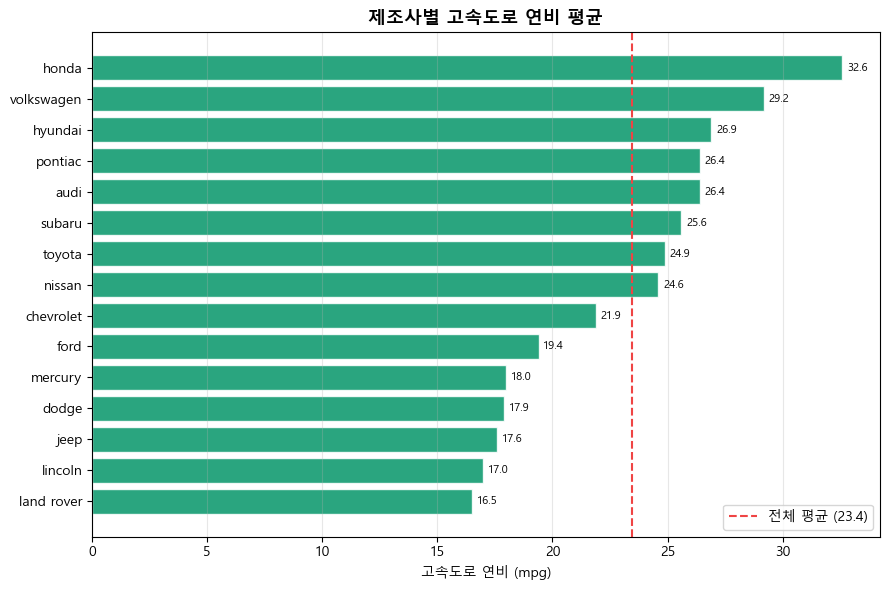

In [15]:
mfr_hwy = df.groupby('manufacturer')['hwy'].mean().round(1).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(mfr_hwy.index, mfr_hwy.values,
               color='#059669', edgecolor='white', alpha=0.85)

# 막대 끝에 수치 표시
for bar, val in zip(bars, mfr_hwy.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
           f'{val}', va='center', fontsize=8)

ax.set_title('제조사별 고속도로 연비 평균', fontsize=13, fontweight='bold')
ax.set_xlabel('고속도로 연비 (mpg)')
ax.axvline(df['hwy'].mean(), color='#ef4444',
          linestyle='--', linewidth=1.5, label=f'전체 평균 ({df["hwy"].mean():.1f})')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

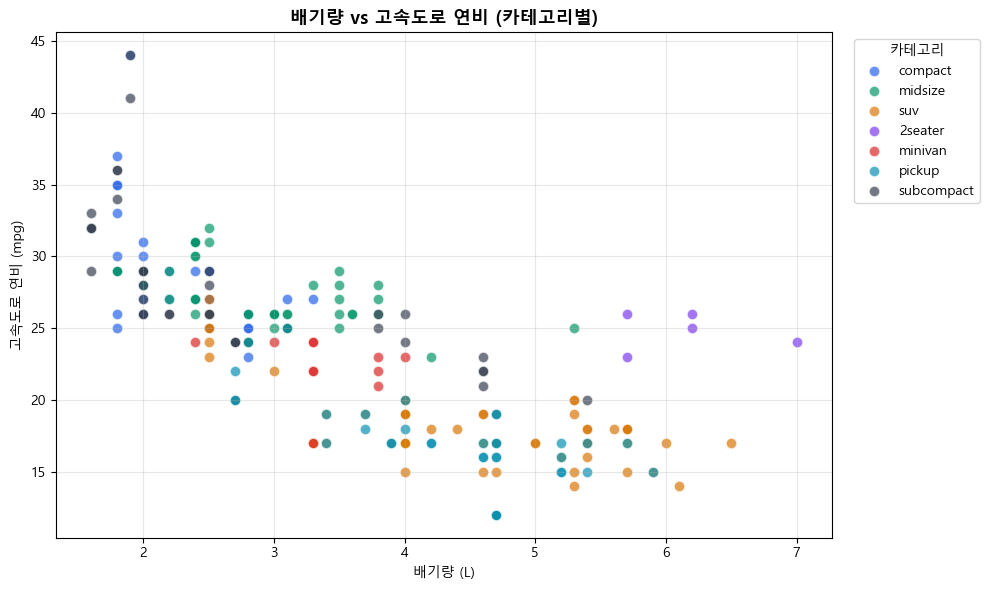

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = df['category'].unique()
colors = ['#2563eb', '#059669', '#d97706', '#7c3aed',
          '#dc2626', '#0891b2', '#374151']

for cat, color in zip(categories, colors):
    subset = df[df['category'] == cat]
    ax.scatter(subset['displ'], subset['hwy'],
               c=color, label=cat, s=60, alpha=0.7, edgecolors='white')

ax.set_title('배기량 vs 고속도로 연비 (카테고리별)', fontsize=13, fontweight='bold')
ax.set_xlabel('배기량 (L)')
ax.set_ylabel('고속도로 연비 (mpg)')
ax.legend(title='카테고리', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23624\522661797.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=cat_order,


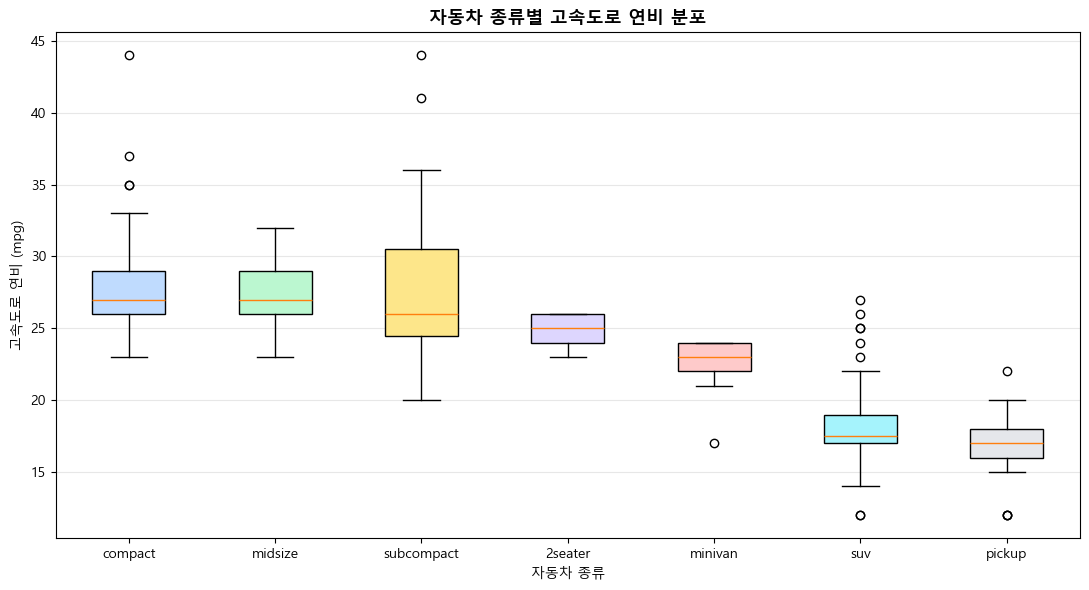

In [17]:
# 카테고리별 고속도로 연비 데이터 준비
cat_order = df.groupby('category')['hwy'].median().sort_values(ascending=False).index
data_by_cat = [df[df['category'] == c]['hwy'].values for c in cat_order]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(data_by_cat, labels=cat_order,
                patch_artist=True, notch=False)

# 박스 색상 지정
box_colors = ['#bfdbfe', '#bbf7d0', '#fde68a', '#ddd6fe',
              '#fecaca', '#a5f3fc', '#e5e7eb']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

ax.set_title('자동차 종류별 고속도로 연비 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('자동차 종류')
ax.set_ylabel('고속도로 연비 (mpg)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

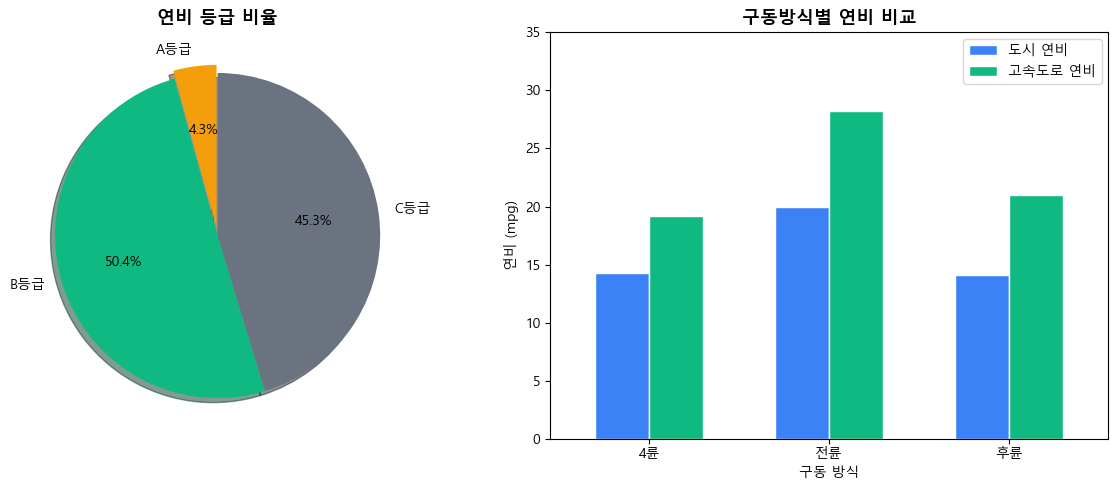

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ① 연비 등급 파이 차트
grade_counts = df['grade'].value_counts().sort_index()
explode = (0.05, 0, 0)
axes[0].pie(grade_counts, labels=['A등급', 'B등급', 'C등급'],
           autopct='%1.1f%%', explode=explode,
           colors=['#f59e0b', '#10b981', '#6b7280'],
           startangle=90, shadow=True)
axes[0].set_title('연비 등급 비율', fontsize=13, fontweight='bold')

# ② 구동방식별 도시/고속도로 연비 비교
drv_mean = df.groupby('drv')[['cty', 'hwy']].mean().round(1)
drv_mean.index = ['4륜', '전륜', '후륜']
drv_mean.plot.bar(ax=axes[1], rot=0, width=0.6,
                 color=['#3b82f6', '#10b981'],
                 edgecolor='white')
axes[1].set_title('구동방식별 연비 비교', fontsize=13, fontweight='bold')
axes[1].set_xlabel('구동 방식')
axes[1].set_ylabel('연비 (mpg)')
axes[1].legend(['도시 연비', '고속도로 연비'])
axes[1].set_ylim(0, 35)
plt.tight_layout()
plt.show()

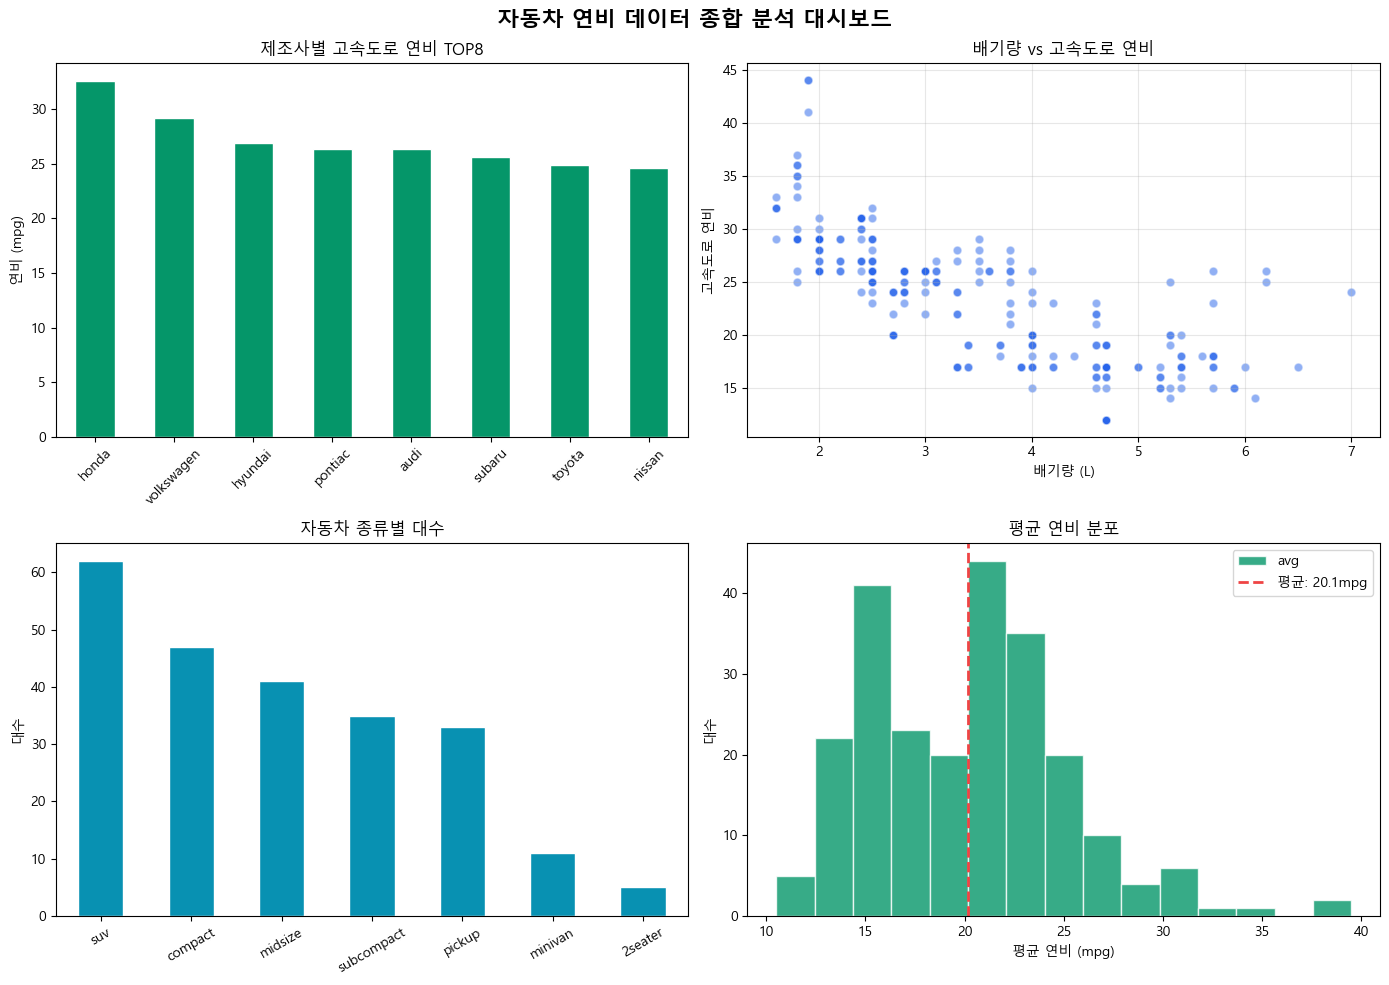

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('자동차 연비 데이터 종합 분석 대시보드', fontsize=16, fontweight='bold')

# [0,0] 상위 10 제조사 고속도로 연비
top_mfr = df.groupby('manufacturer')['hwy'].mean().round(1)
top_mfr = top_mfr.sort_values(ascending=False).head(8)
top_mfr.plot.bar(ax=axes[0, 0], color='#059669', rot=45, edgecolor='white')
axes[0, 0].set_title('제조사별 고속도로 연비 TOP8')
axes[0, 0].set_ylabel('연비 (mpg)')
axes[0, 0].set_xlabel('')

# [0,1] 배기량 vs 연비 산점도
axes[0, 1].scatter(df['displ'], df['hwy'],
                   c='#2563eb', alpha=0.5, s=40, edgecolors='white')
axes[0, 1].set_title('배기량 vs 고속도로 연비')
axes[0, 1].set_xlabel('배기량 (L)')
axes[0, 1].set_ylabel('고속도로 연비')
axes[0, 1].grid(True, alpha=0.3)

# [1,0] 카테고리별 대수 막대
cat_count = df['category'].value_counts()
cat_count.plot.bar(ax=axes[1, 0], color='#0891b2', rot=30, edgecolor='white')
axes[1, 0].set_title('자동차 종류별 대수')
axes[1, 0].set_ylabel('대수')
axes[1, 0].set_xlabel('')

# [1,1] 연비 히스토그램
df['avg'].plot.hist(ax=axes[1, 1], bins=15,
                  color='#059669', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(df['avg'].mean(), color='#ef4444',
                   linestyle='--', linewidth=2,
                   label=f"평균: {df['avg'].mean():.1f}mpg")
axes[1, 1].set_title('평균 연비 분포')
axes[1, 1].set_xlabel('평균 연비 (mpg)')
axes[1, 1].set_ylabel('대수')
axes[1, 1].legend()

plt.tight_layout()
plt.show()